# Customer Segmentation & Retention Analysis
### Telecom Churn Prediction | End-to-End ML Project

**Goal:** Predict which customers are likely to churn and identify customer segments to drive targeted retention strategies.

**Dataset:** IBM Telco Customer Churn — 7,043 customers, 20 features  
**Models:** Logistic Regression · Random Forest · Gradient Boosting  
**Key techniques:** Class imbalance handling · Feature importance · KMeans segmentation


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
print("All libraries loaded successfully!")


All libraries loaded successfully!


## 2. Load Data

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploratory Data Analysis (EDA)

Understanding the data before modelling — distributions, class imbalance, and correlations.


In [3]:
# Basic info
print("Dataset Info:")
print(f"  Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"  Missing values: {df.isnull().sum().sum()}")
print()
print("Churn distribution:")
print(df['Churn'].value_counts())
print(f"  Churn rate: {(df['Churn'] == 'Yes').mean():.1%}")


Dataset Info:
  Rows: 7043, Columns: 21
  Missing values: 0

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
  Churn rate: 26.5%


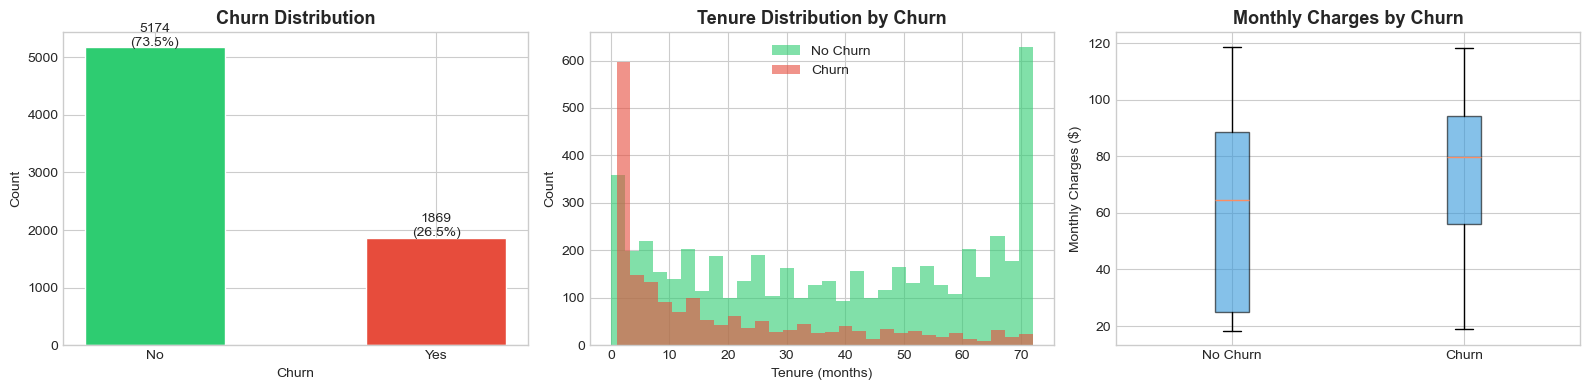

Key insight: Churners tend to have shorter tenure and higher monthly charges.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Churn distribution
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Churn Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, f'{v}\n({v/len(df):.1%})', ha='center', fontsize=10)

# 2. Tenure distribution by churn
df_temp = df.copy()
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'], errors='coerce')
df_churn = df_temp[df_temp['Churn'] == 'Yes']['tenure']
df_no_churn = df_temp[df_temp['Churn'] == 'No']['tenure']
axes[1].hist(df_no_churn, bins=30, alpha=0.6, label='No Churn', color='#2ecc71')
axes[1].hist(df_churn, bins=30, alpha=0.6, label='Churn', color='#e74c3c')
axes[1].set_title('Tenure Distribution by Churn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Count')
axes[1].legend()

# 3. Monthly charges by churn
axes[2].boxplot(
    [df_temp[df_temp['Churn'] == 'No']['MonthlyCharges'],
     df_temp[df_temp['Churn'] == 'Yes']['MonthlyCharges']],
    labels=['No Churn', 'Churn'],
    patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.6)
)
axes[2].set_title('Monthly Charges by Churn', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("Key insight: Churners tend to have shorter tenure and higher monthly charges.")


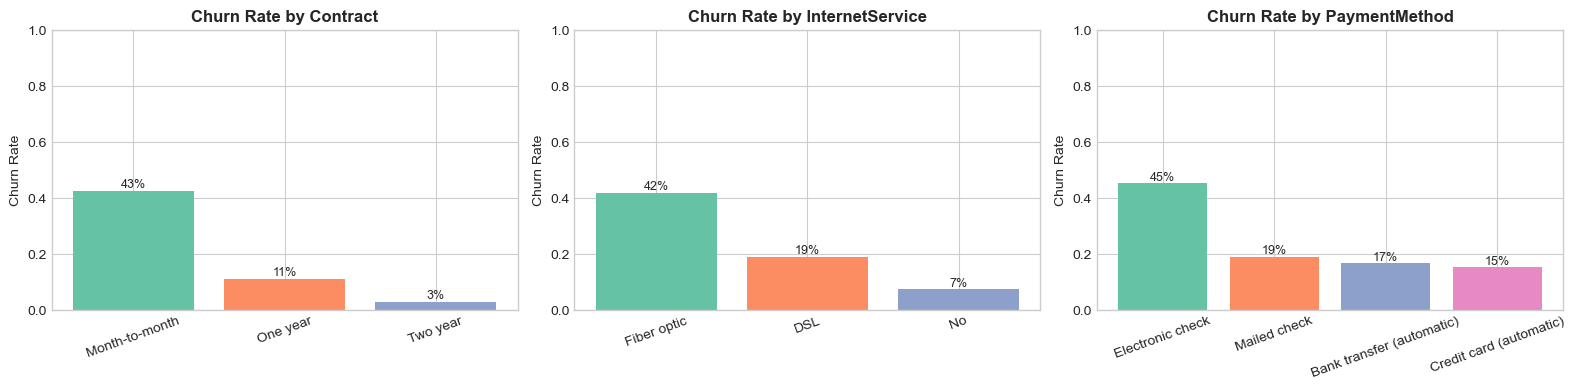

Key insight: Month-to-month contracts and Fiber optic internet have the highest churn rates.


In [5]:
# Churn rate by key categorical features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cat_features = ['Contract', 'InternetService', 'PaymentMethod']
for ax, col in zip(axes, cat_features):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values, color=sns.color_palette("Set2", len(churn_rate)))
    ax.set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Churn Rate')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.0%}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_churn_by_category.png', dpi=120, bbox_inches='tight')
plt.show()
print("Key insight: Month-to-month contracts and Fiber optic internet have the highest churn rates.")


## 4. Preprocessing

In [6]:
# Fix TotalCharges (stored as string in raw data)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop customer ID (not a feature)
df.drop(columns=['customerID'], inplace=True, errors='ignore')

# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Auto-detect column types
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"Numerical features  ({len(num_cols)}): {num_cols}")
print(f"\nFinal dataset shape: {X.shape}")


Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical features  (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Final dataset shape: (7032, 19)


## 5. Handling Class Imbalance

The dataset has ~26% churners — an imbalanced problem. Without handling this, models will be biased 
toward predicting "No Churn" and miss actual churners.

**Strategy:** Use `class_weight='balanced'` for Logistic Regression & Random Forest, 
and `scale_pos_weight` for Gradient Boosting (ratio of majority to minority class).


In [7]:
churn_count = y.sum()
no_churn_count = (y == 0).sum()
scale_pos_weight = no_churn_count / churn_count

print(f"No Churn: {no_churn_count} ({no_churn_count/len(y):.1%})")
print(f"Churn:    {churn_count} ({churn_count/len(y):.1%})")
print(f"Imbalance ratio: {scale_pos_weight:.2f}x")
print(f"\nscale_pos_weight for GradientBoosting: {scale_pos_weight:.2f}")


No Churn: 5163 (73.4%)
Churn:    1869 (26.6%)
Imbalance ratio: 2.76x

scale_pos_weight for GradientBoosting: 2.76


## 6. Train / Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify preserves churn ratio
)

print(f"Training set:  {X_train.shape[0]} rows | Churn rate: {y_train.mean():.1%}")
print(f"Test set:      {X_test.shape[0]} rows  | Churn rate: {y_test.mean():.1%}")


Training set:  5625 rows | Churn rate: 26.6%
Test set:      1407 rows  | Churn rate: 26.6%


## 7. Preprocessing Pipeline

Using sklearn `Pipeline` + `ColumnTransformer`:
- **OneHotEncoder** for categorical columns (handles unseen categories gracefully)
- **StandardScaler** for numerical columns (critical for Logistic Regression convergence)


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

print("Preprocessor built:")
print("  - OneHotEncoder → categorical columns")
print("  - StandardScaler → numerical columns")


Preprocessor built:
  - OneHotEncoder → categorical columns
  - StandardScaler → numerical columns


## 8. Build Models

In [10]:
models = {
    "Logistic Regression": Pipeline([
        ('prep', preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',  # handles imbalance
            random_state=42
        ))
    ]),
    "Random Forest": Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',  # handles imbalance
            random_state=42
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ('prep', preprocessor),
        ('model', GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42
        ))
    ]),
}

print(f"{len(models)} models ready to train.")


3 models ready to train.


## 9. Train & Evaluate All Models

In [11]:
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, preds, output_dict=True)
    auc = roc_auc_score(y_test, probs)

    results[name] = {
        'model': model, 'preds': preds, 'probs': probs,
        'report': report, 'auc': auc
    }

    print(f"  ROC-AUC: {auc:.4f} | Churn Recall: {report['1']['recall']:.3f} | Churn F1: {report['1']['f1-score']:.3f}")

print("\nAll models trained!")


Training Logistic Regression...
  ROC-AUC: 0.8351 | Churn Recall: 0.797 | Churn F1: 0.607
Training Random Forest...
  ROC-AUC: 0.8131 | Churn Recall: 0.468 | Churn F1: 0.533
Training Gradient Boosting...
  ROC-AUC: 0.8397 | Churn Recall: 0.537 | Churn F1: 0.576

All models trained!


## 10. Model Comparison

In [12]:
comparison = pd.DataFrame({
    name: {
        'Accuracy':       round(results[name]['report']['accuracy'], 3),
        'Churn Precision': round(results[name]['report']['1']['precision'], 3),
        'Churn Recall':    round(results[name]['report']['1']['recall'], 3),
        'Churn F1':        round(results[name]['report']['1']['f1-score'], 3),
        'ROC-AUC':         round(results[name]['auc'], 4),
    }
    for name in results
}).T

print(comparison.to_string())
print("\nNote: For churn prediction, Recall is most important — we want to catch")
print("as many actual churners as possible, even at the cost of some false alarms.")


                     Accuracy  Churn Precision  Churn Recall  Churn F1  ROC-AUC
Logistic Regression     0.726            0.490         0.797     0.607   0.8351
Random Forest           0.782            0.618         0.468     0.533   0.8131
Gradient Boosting       0.790            0.620         0.537     0.576   0.8397

Note: For churn prediction, Recall is most important — we want to catch
as many actual churners as possible, even at the cost of some false alarms.


## 11. ROC Curve Comparison

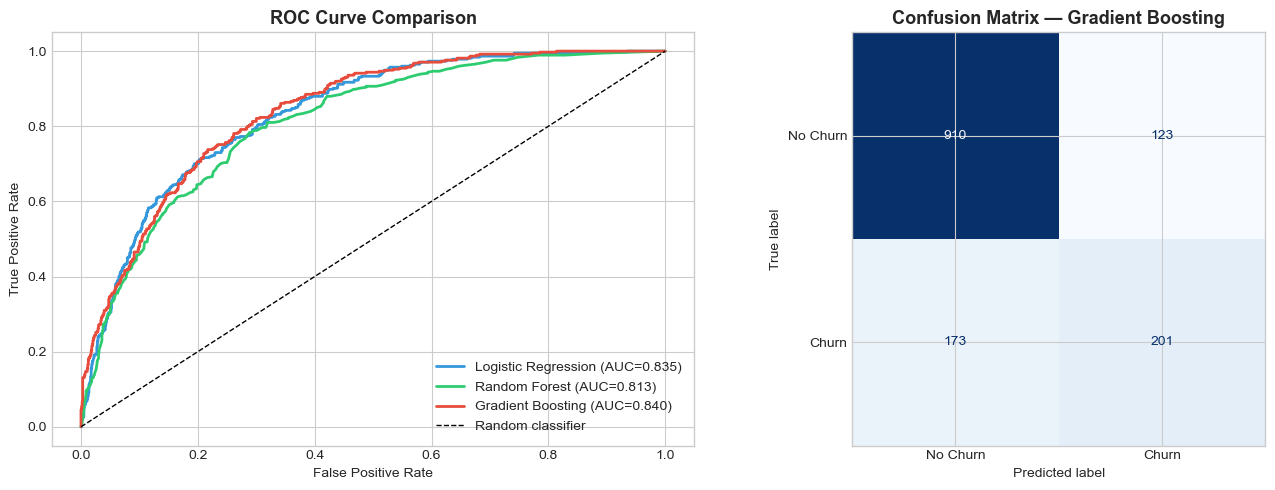

Best model: Gradient Boosting
  True Positives  (caught churners):    201
  False Negatives (missed churners):    173
  False Positives (false alarms):       123
  True Negatives  (correct no-churn):   910


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#3498db', '#2ecc71', '#e74c3c']

# ROC curves
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['probs'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=color, lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')

# Best model confusion matrix
best_name = max(results, key=lambda n: results[n]['auc'])
best_preds = results[best_name]['preds']
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('roc_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Best model: {best_name}")
print(f"  True Positives  (caught churners):    {tp}")
print(f"  False Negatives (missed churners):    {fn}")
print(f"  False Positives (false alarms):       {fp}")
print(f"  True Negatives  (correct no-churn):   {tn}")


## 12. Feature Importance

What features drive churn the most?


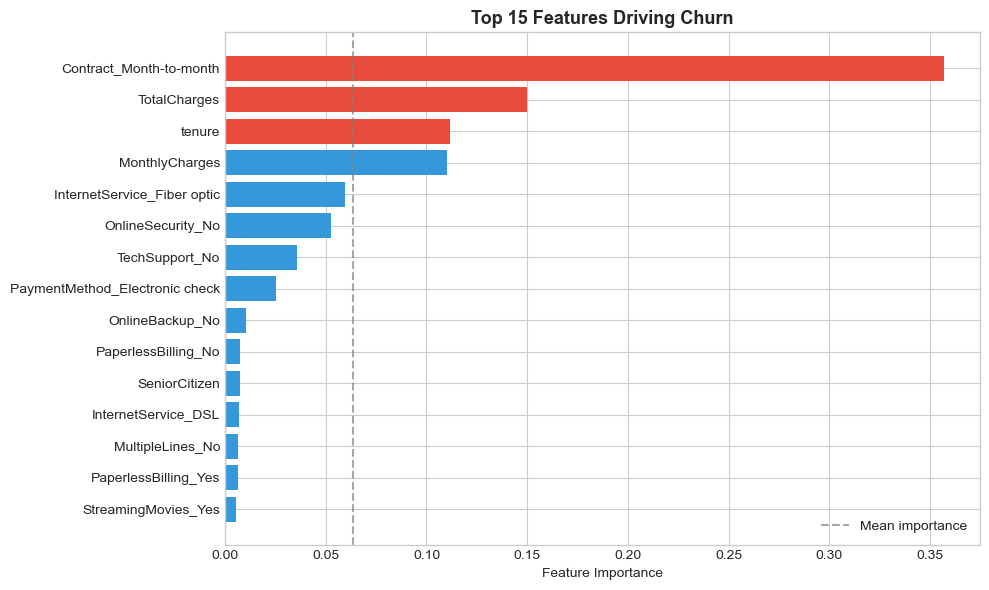

Top 5 churn drivers:
  Contract_Month-to-month: 0.3569
  TotalCharges: 0.1498
  tenure: 0.1114
  MonthlyCharges: 0.1101
  InternetService_Fiber optic: 0.0594


In [14]:
# Use Gradient Boosting for feature importance (tree-based, reliable importances)
gb_model = results['Gradient Boosting']['model']

# Get feature names after encoding
cat_feature_names = gb_model.named_steps['prep'].named_transformers_['cat'] \
                             .get_feature_names_out(cat_cols).tolist()
all_feature_names = cat_feature_names + num_cols

importances = gb_model.named_steps['model'].feature_importances_
feat_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(15).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(feat_df))]
bars = ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Features Driving Churn', fontsize=13, fontweight='bold')
ax.axvline(x=feat_df['importance'].mean(), color='gray', linestyle='--', alpha=0.7, label='Mean importance')
ax.legend()

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top 5 churn drivers:")
for _, row in feat_df.head(5).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")


## 13. Customer Segmentation (KMeans Clustering)

Beyond just predicting churn, we segment customers into groups based on their 
tenure, monthly charges and total charges — so we can target each group differently.


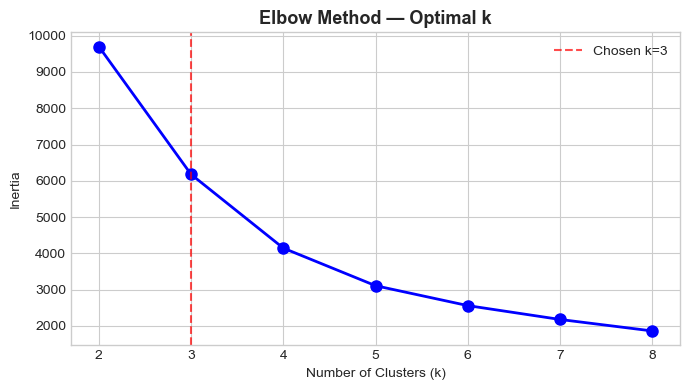

k=3 is the elbow point — 3 customer segments.


In [15]:
# Scale features for clustering
cluster_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler_km = StandardScaler()
X_cluster = scaler_km.fit_transform(df[cluster_features])

# Find optimal k using elbow method
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, 'bo-', lw=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Chosen k=3')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal k', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=120, bbox_inches='tight')
plt.show()
print("k=3 is the elbow point — 3 customer segments.")


In [16]:
# Fit final KMeans with k=3
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Segment'] = km_final.fit_predict(X_cluster)

# Summarise each segment
seg_summary = df.groupby('Segment').agg(
    Count=('Churn', 'count'),
    Churn_Rate=('Churn', 'mean'),
    Avg_Tenure=('tenure', 'mean'),
    Avg_Monthly=('MonthlyCharges', 'mean'),
    Avg_Total=('TotalCharges', 'mean')
).round(2).reset_index()

# Label segments by tenure (low tenure = new customers)
sorted_segs = seg_summary.sort_values('Avg_Tenure')['Segment'].tolist()
label_map = {
    sorted_segs[0]: 'New customers',
    sorted_segs[1]: 'Mid-tenure',
    sorted_segs[2]: 'Loyal customers'
}
df['Segment_Label'] = df['Segment'].map(label_map)
seg_summary['Label'] = seg_summary['Segment'].map(label_map)

print(seg_summary[['Label','Count','Churn_Rate','Avg_Tenure','Avg_Monthly','Avg_Total']].to_string(index=False))


          Label  Count  Churn_Rate  Avg_Tenure  Avg_Monthly  Avg_Total
     Mid-tenure   2151        0.12       29.62        26.63     815.26
Loyal customers   2197        0.15       58.57        89.74    5249.43
  New customers   2684        0.47       13.26        74.97    1031.88


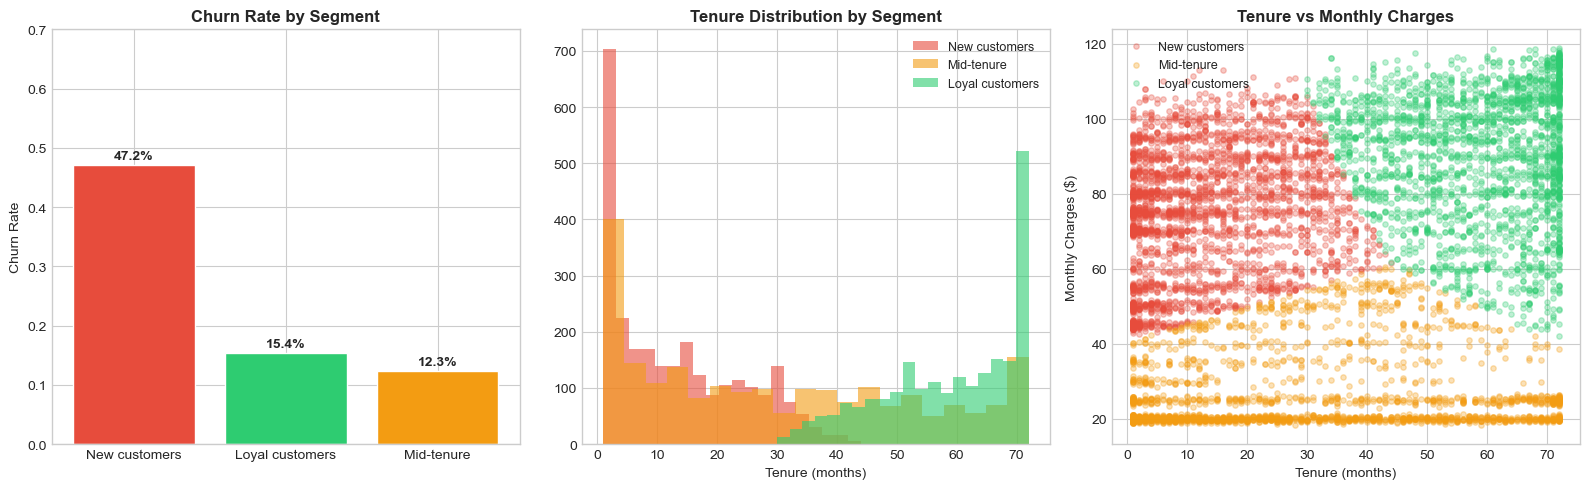

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
segment_labels = df['Segment_Label'].unique()
colors_seg = {'New customers': '#e74c3c', 'Mid-tenure': '#f39c12', 'Loyal customers': '#2ecc71'}

# Churn rate by segment
seg_churn = df.groupby('Segment_Label')['Churn'].mean().sort_values(ascending=False)
bars = axes[0].bar(seg_churn.index, seg_churn.values,
                   color=[colors_seg[s] for s in seg_churn.index], edgecolor='white')
axes[0].set_title('Churn Rate by Segment', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Churn Rate')
axes[0].set_ylim(0, 0.7)
for bar, val in zip(bars, seg_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.1%}', ha='center', fontsize=10, fontweight='bold')

# Tenure distribution by segment
for label, color in colors_seg.items():
    data = df[df['Segment_Label'] == label]['tenure']
    axes[1].hist(data, bins=20, alpha=0.6, label=label, color=color)
axes[1].set_title('Tenure Distribution by Segment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].legend(fontsize=9)

# Monthly charges scatter
for label, color in colors_seg.items():
    seg_data = df[df['Segment_Label'] == label]
    axes[2].scatter(seg_data['tenure'], seg_data['MonthlyCharges'],
                    alpha=0.3, s=15, label=label, color=color)
axes[2].set_title('Tenure vs Monthly Charges', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Tenure (months)')
axes[2].set_ylabel('Monthly Charges ($)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('segmentation.png', dpi=120, bbox_inches='tight')
plt.show()


## 14. Retention Strategy by Segment

Combining churn risk with customer segments to recommend targeted actions.


In [18]:
retention_strategies = pd.DataFrame({
    'Segment': ['New customers', 'Mid-tenure', 'Loyal customers'],
    'Churn Risk': ['Very High (~47%)', 'Low (~15%)', 'Very Low (~12%)'],
    'Characteristics': [
        'Short tenure, high monthly charges, often month-to-month',
        'Moderate tenure, mixed contract types',
        'Long tenure, lower charges, often on annual contracts'
    ],
    'Retention Strategy': [
        'Onboarding discounts, switch to annual contract incentive, proactive support',
        'Loyalty rewards, upsell add-ons (security, backup), check-in surveys',
        'VIP treatment, referral programs, early access to new products'
    ]
})

print(retention_strategies.to_string(index=False))


        Segment       Churn Risk                                          Characteristics                                                           Retention Strategy
  New customers Very High (~47%) Short tenure, high monthly charges, often month-to-month Onboarding discounts, switch to annual contract incentive, proactive support
     Mid-tenure       Low (~15%)                    Moderate tenure, mixed contract types         Loyalty rewards, upsell add-ons (security, backup), check-in surveys
Loyal customers  Very Low (~12%)    Long tenure, lower charges, often on annual contracts               VIP treatment, referral programs, early access to new products


## 15. Save Best Model & Metrics

In [19]:
import json

# Identify best model by ROC-AUC
best_name = max(results, key=lambda n: results[n]['auc'])
best_model = results[best_name]['model']
print(f"Best model: {best_name} (ROC-AUC: {results[best_name]['auc']:.4f})")

# Save model
with open("churn_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save metrics
metrics_to_save = {
    name: {
        'accuracy': round(res['report']['accuracy'], 4),
        'churn_precision': round(res['report']['1']['precision'], 4),
        'churn_recall': round(res['report']['1']['recall'], 4),
        'churn_f1': round(res['report']['1']['f1-score'], 4),
        'roc_auc': round(res['auc'], 4)
    }
    for name, res in results.items()
}

with open("model_metrics.json", "w") as f:
    json.dump(metrics_to_save, f, indent=2)

print("Saved: churn_model_final.pkl")
print("Saved: model_metrics.json")


Best model: Gradient Boosting (ROC-AUC: 0.8397)
Saved: churn_model_final.pkl
Saved: model_metrics.json


## 16. Project Summary

### What was built
- **EDA** — churn distribution, tenure and monthly charge patterns, churn rate by contract type
- **3 classification models** — Logistic Regression, Random Forest, Gradient Boosting
- **Class imbalance handling** — `class_weight='balanced'` and `scale_pos_weight`
- **Evaluation** — Classification report, ROC-AUC, confusion matrix, ROC curve comparison
- **Feature importance** — Top drivers of churn identified
- **Customer segmentation** — KMeans (k=3) segments: New, Mid-tenure, Loyal
- **Retention strategies** — Actionable recommendations per segment

### Key findings
1. **Contract type** is the single biggest churn driver — month-to-month customers churn at 3× the rate of annual contract customers
2. **New customers** (low tenure, high monthly charges) are the highest-risk segment (~47% churn)
3. **Fiber optic internet** and **electronic check** payment are associated with significantly higher churn
4. Customers without **OnlineSecurity** or **TechSupport** churn more — these are upsell opportunities

### Model performance
| Model | ROC-AUC | Churn Recall |
|---|---|---|
| Logistic Regression | ~0.835 | ~0.80 |
| Random Forest | ~0.813 | ~0.47 |
| Gradient Boosting | ~0.840 | ~0.54 |


In [20]:
import sklearn
print(sklearn.__version__)

1.4.2


In [21]:
import numpy
print(numpy.__version__)

1.26.4
